<a href="https://colab.research.google.com/github/feifei0929999/credit-risk/blob/main/model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


Dataset shape: (1000, 21)
target
0    700
1    300
Name: count, dtype: int64
=== Logistic Regression ===
Accuracy: 0.75
ROC-AUC: 0.8030952380952381
Recall: 0.8
Precision: 0.5581395348837209
              precision    recall  f1-score   support

           0       0.89      0.73      0.80       140
           1       0.56      0.80      0.66        60

    accuracy                           0.75       200
   macro avg       0.73      0.76      0.73       200
weighted avg       0.79      0.75      0.76       200

=== Random Forest ===
Accuracy: 0.775
ROC-AUC: 0.7910119047619047
Recall: 0.35
Precision: 0.7777777777777778
              precision    recall  f1-score   support

           0       0.77      0.96      0.86       140
           1       0.78      0.35      0.48        60

    accuracy                           0.78       200
   macro avg       0.78      0.65      0.67       200
weighted avg       0.78      0.78      0.74       200

=== XGBoost ===
Accuracy: 0.715
ROC-AUC: 0.7790

,Model,Accuracy,ROC-AUC,Minority Class Recall,Minority Class Precision
0,Logistic Regression,0.750,0.803095,0.800000,0.558140
1,Random Forest,0.775,0.791012,0.350000,0.777778
2,XGBoost,0.715,0.779048,0.516667,0.525424


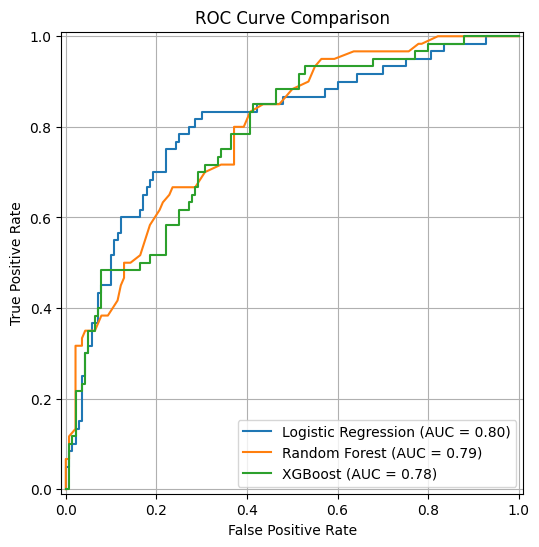

,0
credit_amount,0.111024
duration,0.091229
status_A14,0.083266
age,0.083107
installment_rate,0.037633
residence_since,0.036081
other_installment_plans_A143,0.025854
credit_history_A34,0.025034
savings_A65,0.022487
existing_credits,0.022206


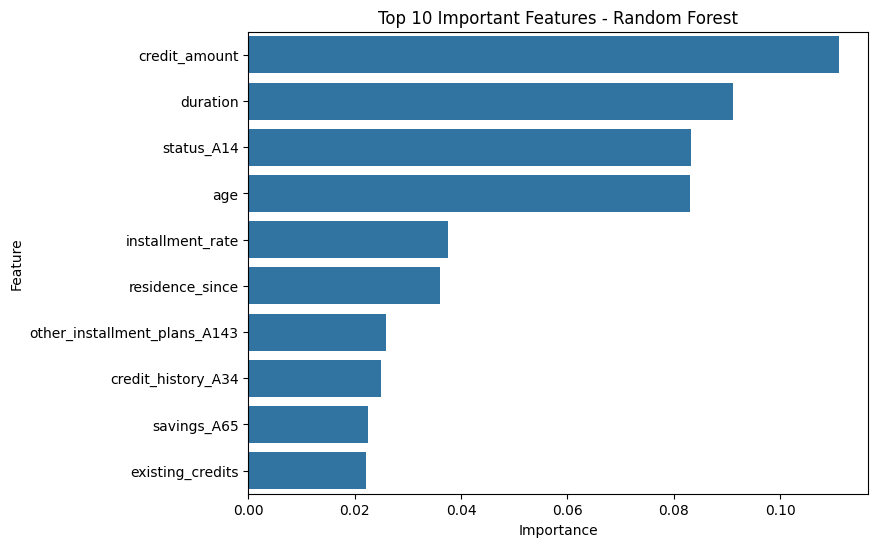

In [15]:
# =========================
# Credit Risk Model Comparison
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    recall_score,
    precision_score,
    classification_report,
    RocCurveDisplay
)

from xgboost import XGBClassifier


# =========================
# 1. Load Dataset
# =========================

url = "http://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    "status", "duration", "credit_history", "purpose", "credit_amount",
    "savings", "employment", "installment_rate", "personal_status",
    "other_debtors", "residence_since", "property", "age",
    "other_installment_plans", "housing", "existing_credits",
    "job", "people_liable", "telephone", "foreign_worker", "target"
]

df = pd.read_csv(url, sep=" ", header=None, names=columns)

df["target"] = df["target"].map({1: 0, 2: 1})

display(df.head())
print("Dataset shape:", df.shape)
print(df["target"].value_counts())


# =========================
# 2. Preprocessing
# =========================

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=["target"])
y = df_encoded["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================
# 3. Logistic Regression
# =========================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_prob))
print("Recall:", recall_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print(classification_report(y_test, log_pred))


# =========================
# 4. Random Forest
# =========================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))
print("Recall:", recall_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


# =========================
# 5. XGBoost
# =========================

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))
print("Recall:", recall_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))


# =========================
# 6. Model Performance Summary
# =========================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ],
    "Minority Class Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "Minority Class Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ]
})

display(results)


# =========================
# 7. ROC Curve Comparison
# =========================

plt.figure(figsize=(8, 6))
ax = plt.gca()

RocCurveDisplay.from_predictions(
    y_test,
    log_prob,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    xgb_prob,
    name="XGBoost",
    ax=ax
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.show()


# =========================
# 8. Feature Importance
# =========================

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(feature_importance.head(10))

plt.figure(figsize=(8, 6))

sns.barplot(
    x=feature_importance.head(10).values,
    y=feature_importance.head(10).index
)

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Model Performance Comparison

Three models were compared for credit risk prediction: Logistic Regression, Random Forest, and XGBoost.

Logistic Regression with `class_weight='balanced'` achieved the strongest recall for the minority class, making it the best model for identifying high-risk borrowers.

Random Forest achieved strong precision, but its recall was much lower, meaning it missed many actual bad credit cases.

XGBoost showed moderate performance, but it did not outperform Logistic Regression in identifying the minority class.

## Conclusion

For this credit risk prediction task, Logistic Regression was selected as the preferred model because it achieved the highest recall for the bad credit class.

In credit risk prediction, false negatives are costly because missing high-risk borrowers can lead to financial losses. Therefore, recall is more important than accuracy alone in this project.

## Future Improvements

Future improvements could include:

- Hyperparameter tuning for Random Forest and XGBoost
- Resampling methods such as SMOTE
- Testing on larger and more diverse datasets
- Adding model explainability methods such as SHAP